### Experiment 2: Email Spam/Ham Classification using Naive Bayes and KNN
#### Hemnath D - 3122247001022 (MTech Integrated CSE)

Aim: To create spam classifiers on the Spambase dataset using Gaussian, Multinomial and Bernoulli Naive Bayes and KNN. To compare the three Naive Bayes variants, study the effect of varying k, compare KDTree and BallTree, tune KNN with GridSearchCV and RandomizedSearchCV, check computational complexity and execution time, and evaluate with K-Fold cross validation.

In [ ]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)

sys.path.append('../Experiment 1')
import preprocessing as pp
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 600})

RANDOM_STATE = 42

##### Loading the dataset
Spambase has 57 numeric features (word and character frequencies plus a few capital letter run length stats) and a class column (1 for spam and 0 for ham)

In [114]:
def load_spam_data(path='spambase.csv', target_col='class'):
    df = pd.read_csv(path)
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return df, X, y

In [115]:
df_spam, X, y = load_spam_data('spambase.csv')
df_spam.shape

(4601, 58)

##### Exploratory analysis

In [116]:
def plot_class_distribution(y, dataset):
    counts = y.value_counts().sort_index()
    plt.figure(figsize=(5, 3.5))
    sns.barplot(x=counts.index.astype(str), y=counts.values, hue=counts.index.astype(str), palette=['seagreen', 'indianred'], legend=False)
    plt.xticks([0, 1], ['Ham (0)', 'Spam (1)'])
    plt.ylabel('Count')
    plt.title(f'Class Distribution ({dataset})')
    pp.save_plot(dataset, 'class-distribution')
    return counts

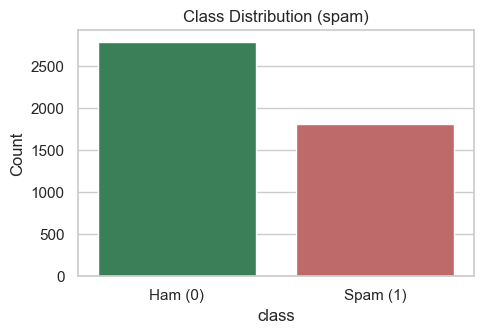

class
0    2788
1    1813
Name: count, dtype: int64

In [117]:
plot_class_distribution(y, 'spam')

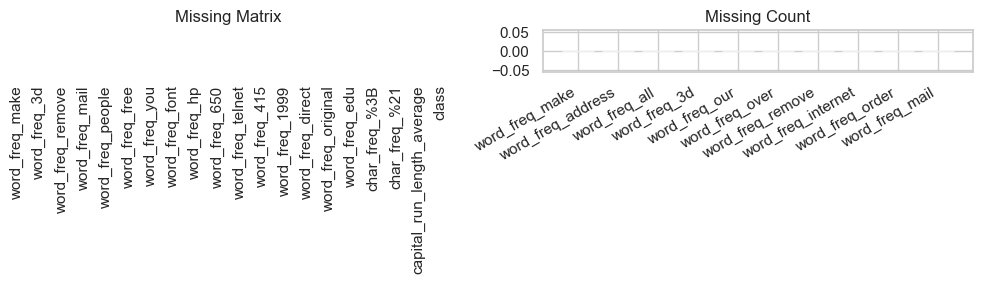

Overall missing rate is 0.00% across all cells
0 column(s) contain missing values


In [118]:
pp.check_missing_values(df_spam, 'spam')

In [119]:
key_cols = pp.pick_key_columns(df_spam, target_col='class', max_cols=10)
print("Choosing only top 10 columns")
key_cols

Choosing only top 10 columns


['capital_run_length_total',
 'capital_run_length_longest',
 'capital_run_length_average',
 'word_freq_george',
 'word_freq_you',
 'word_freq_hp',
 'word_freq_3d',
 'word_freq_address',
 'word_freq_your',
 'word_freq_font']

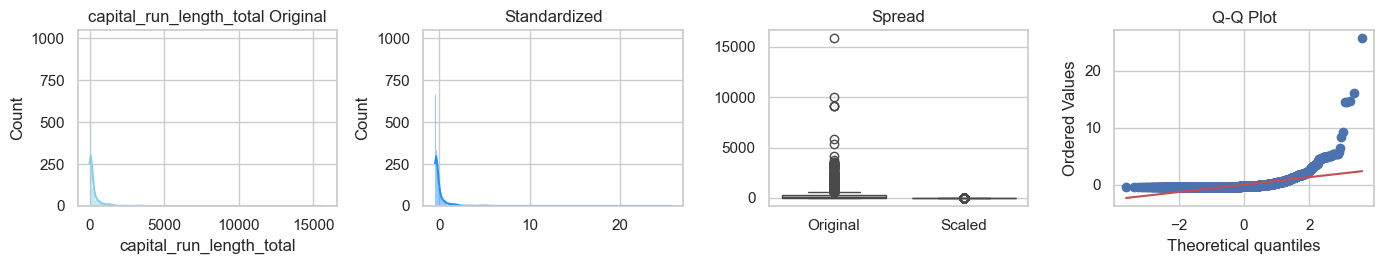

Shapiro-Wilk test on 'capital_run_length_total': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


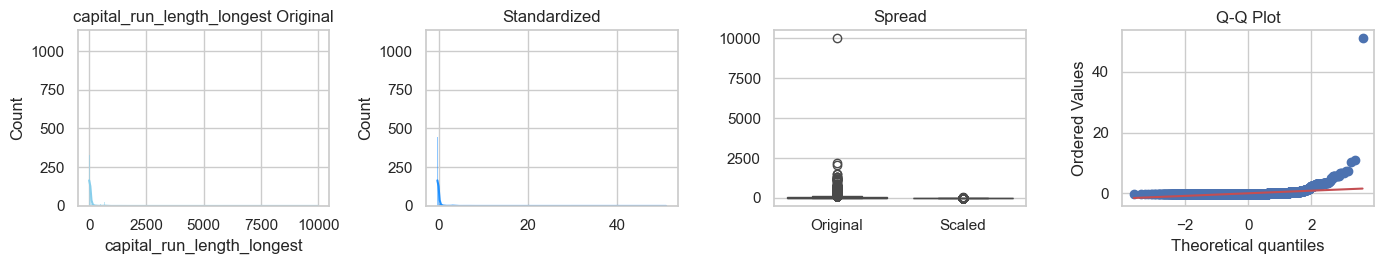

Shapiro-Wilk test on 'capital_run_length_longest': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


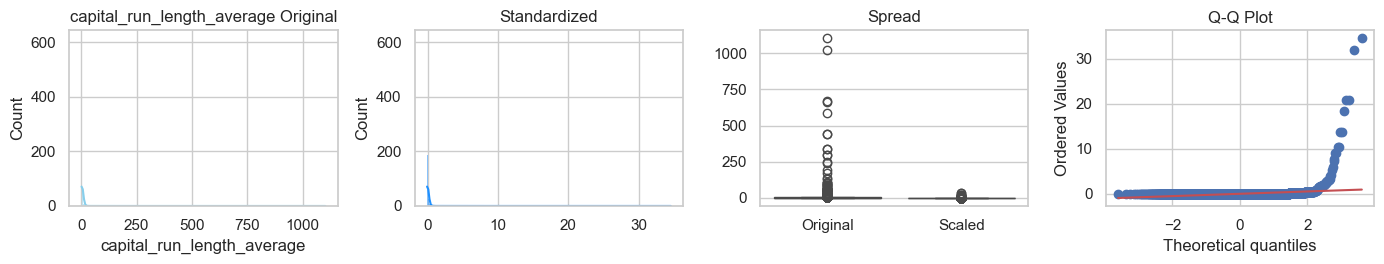

Shapiro-Wilk test on 'capital_run_length_average': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


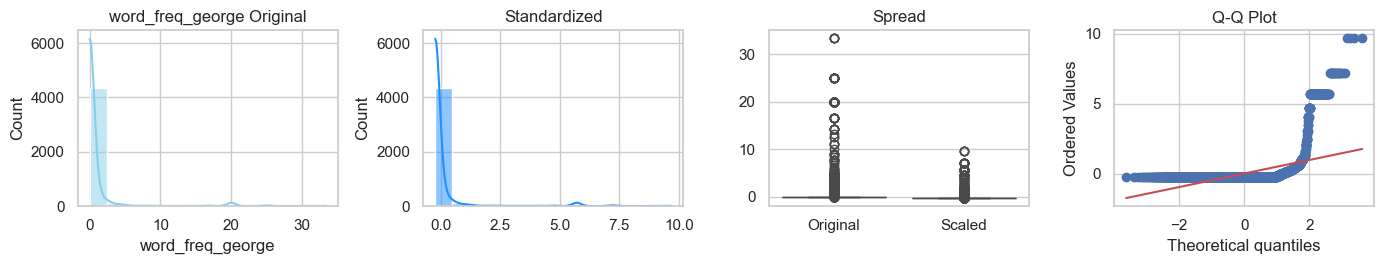

Shapiro-Wilk test on 'word_freq_george': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


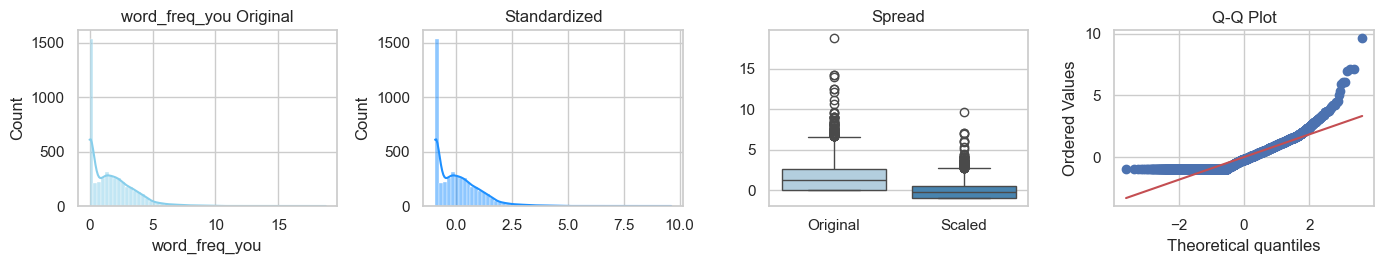

Shapiro-Wilk test on 'word_freq_you': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


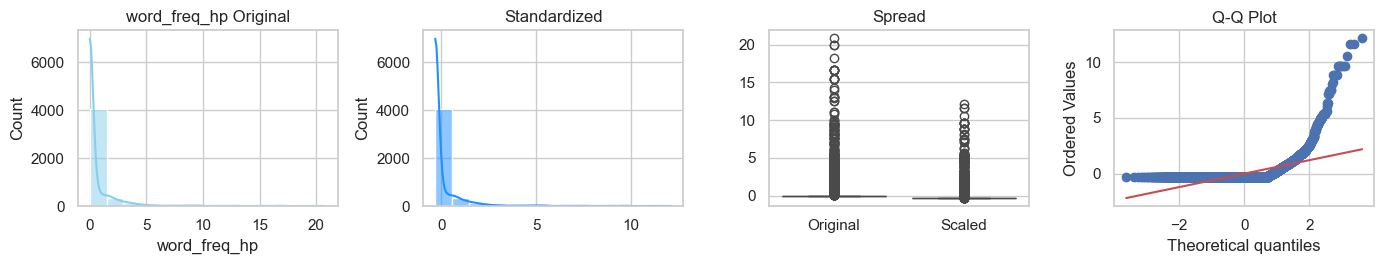

Shapiro-Wilk test on 'word_freq_hp': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


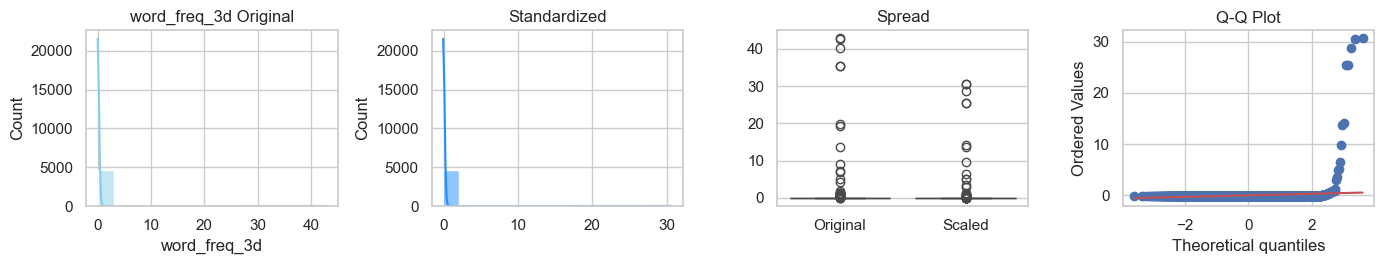

Shapiro-Wilk test on 'word_freq_3d': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


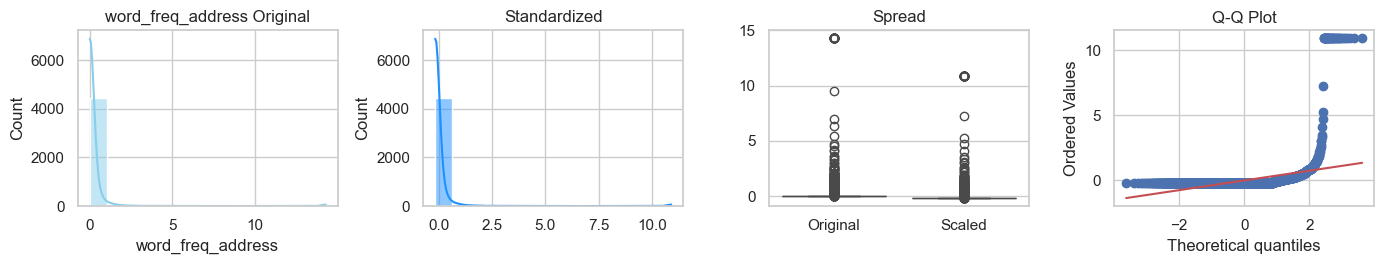

Shapiro-Wilk test on 'word_freq_address': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


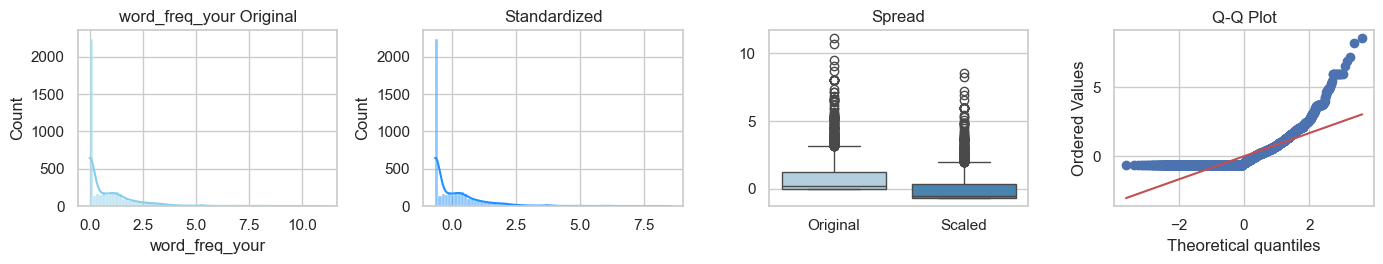

Shapiro-Wilk test on 'word_freq_your': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


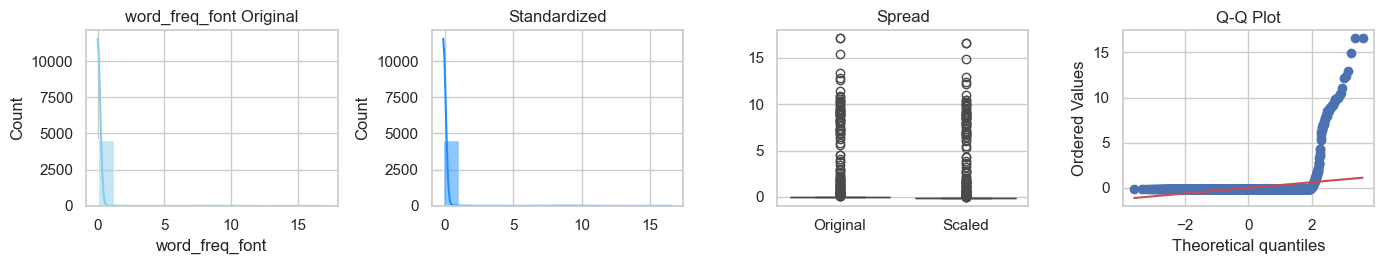

Shapiro-Wilk test on 'word_freq_font': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


In [120]:
pp.check_normality(df_spam, key_cols, 'spam')

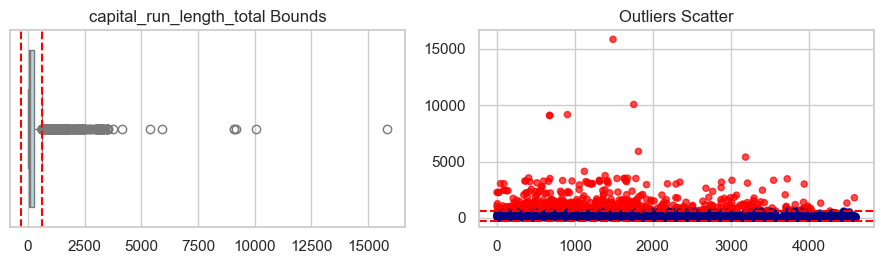

550 of 4601 values in 'capital_run_length_total' are outliers (outside [-311.50, 612.50]).


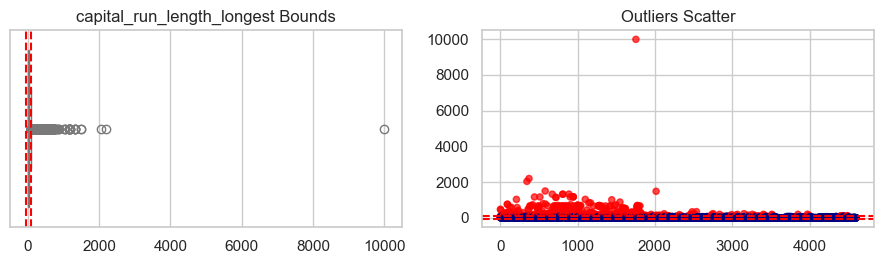

463 of 4601 values in 'capital_run_length_longest' are outliers (outside [-49.50, 98.50]).


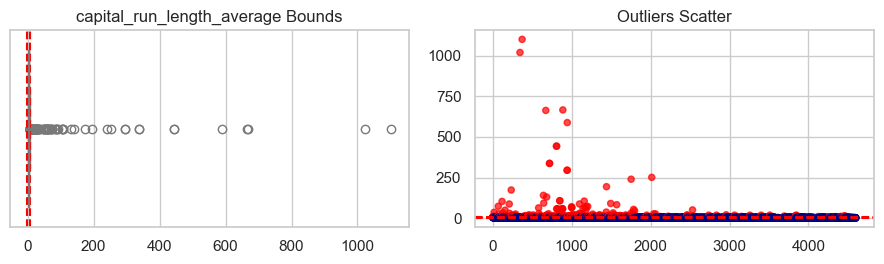

363 of 4601 values in 'capital_run_length_average' are outliers (outside [-1.59, 6.88]).


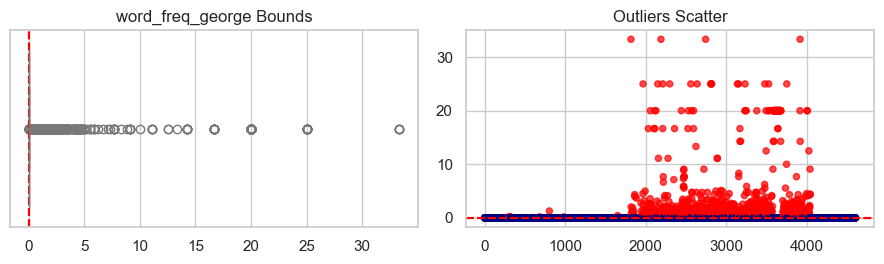

780 of 4601 values in 'word_freq_george' are outliers (outside [0.00, 0.00]).


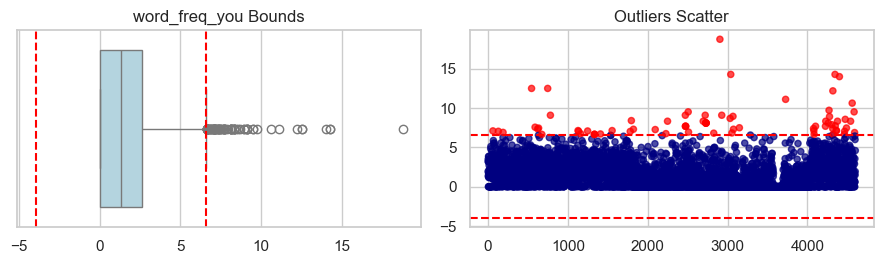

75 of 4601 values in 'word_freq_you' are outliers (outside [-3.96, 6.60]).


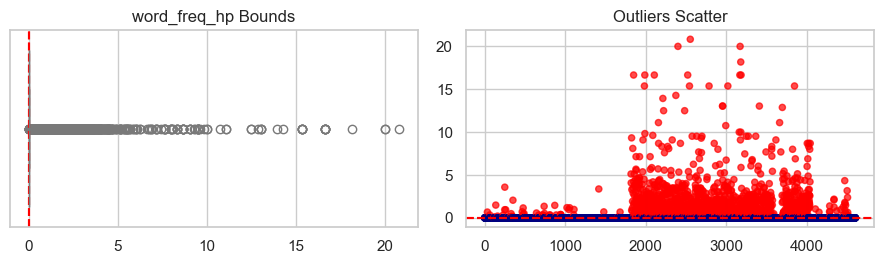

1090 of 4601 values in 'word_freq_hp' are outliers (outside [0.00, 0.00]).


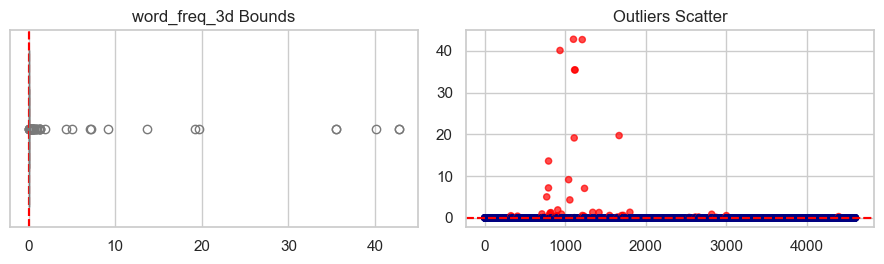

47 of 4601 values in 'word_freq_3d' are outliers (outside [0.00, 0.00]).


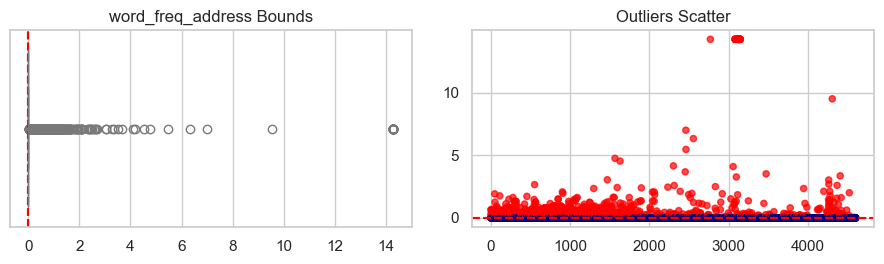

898 of 4601 values in 'word_freq_address' are outliers (outside [0.00, 0.00]).


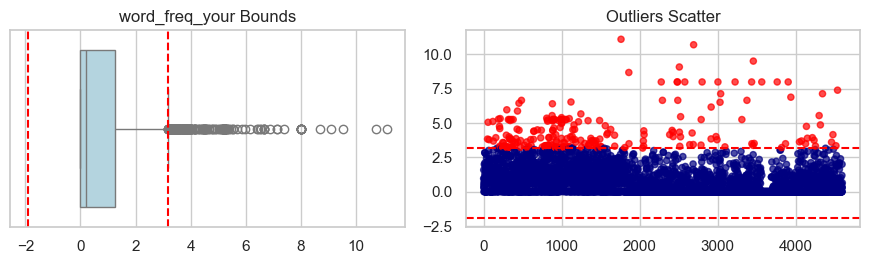

229 of 4601 values in 'word_freq_your' are outliers (outside [-1.91, 3.17]).


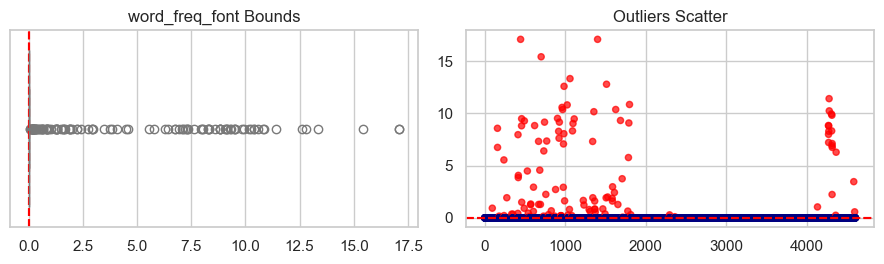

117 of 4601 values in 'word_freq_font' are outliers (outside [0.00, 0.00]).


In [121]:
pp.find_outliers(df_spam, key_cols, 'spam')

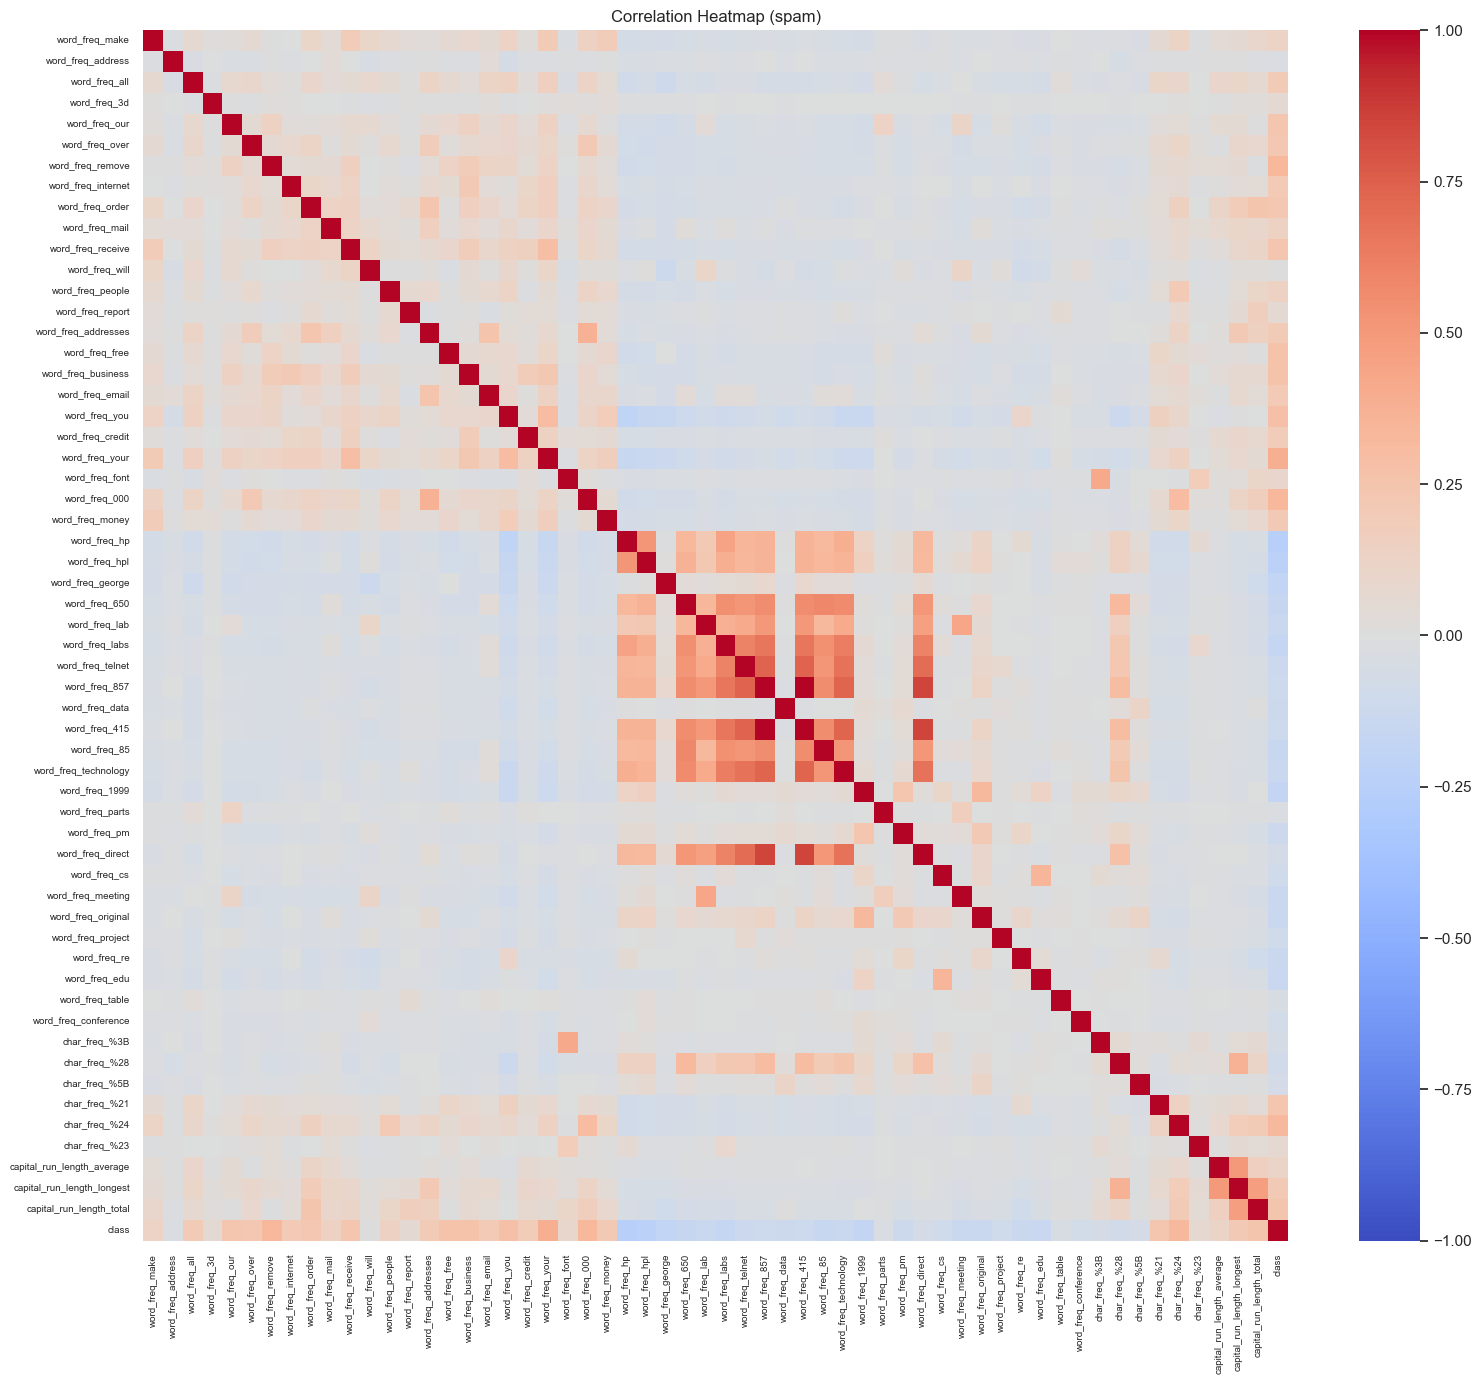

Strongest pairwise correlation is between 'word_freq_857' and 'word_freq_415' (r = 1.00)


In [122]:
pp.plot_correlation(df_spam, 'spam')

Naive Bayes and KNN both do better on a common scale but Multinomial/Bernoulli NB specifically need non-negative input so every feature is min-max normalized into [0, 1] using the normalize_column function applied one column at a time rather than z-score standardizing because it might introduce negative values

In [123]:
def normalize_features(X, normalize_fn=pp.normalize_column):
    X_norm = X.copy()
    for col in X.columns:
        X_norm[col] = normalize_fn(X, col)
    return X_norm

In [124]:
X_norm = normalize_features(X)
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train.shape, X_test.shape

((3680, 57), (921, 57))

##### Functions to train a model and return its predictions, to turn predictions into the standard set of metrics

In [125]:
def train_model(model, X_train, y_train, X_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    return model, y_pred, y_proba

In [126]:
def get_classification_metrics(y_test, y_pred, y_proba=None):
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
    }
    metrics['ROC-AUC'] = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    return metrics

In [127]:
def plot_confusion_matrix(y_test, y_pred, model_name, dataset):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix: {model_name}')
    pp.save_plot(dataset, f'confusion-{model_name.lower().replace(" ", "-")}')

In [128]:
def plot_roc_curves(results, dataset):
    plt.figure(figsize=(6, 5))
    for name, (y_test_i, y_proba_i) in results.items():
        if y_proba_i is None:
            continue
        fpr, tpr, _ = roc_curve(y_test_i, y_proba_i)
        auc = roc_auc_score(y_test_i, y_proba_i)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves ({dataset})')
    plt.legend()
    pp.save_plot(dataset, 'roc-curves')

In [129]:
def plot_precision_recall_curves(results, dataset):
    plt.figure(figsize=(6, 5))
    for name, (y_test_i, y_proba_i) in results.items():
        if y_proba_i is None:
            continue
        prec, rec, _ = precision_recall_curve(y_test_i, y_proba_i)
        plt.plot(rec, prec, label=name)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curves ({dataset})')
    plt.legend()
    pp.save_plot(dataset, 'precision-recall-curves')

##### Training the three Naive Bayes variants and comparison

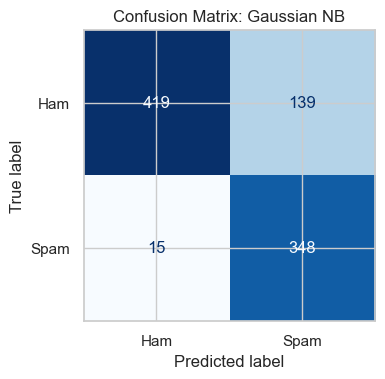

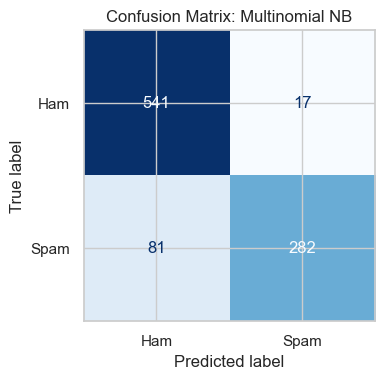

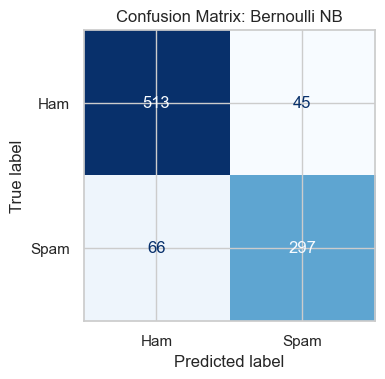

,Accuracy,Precision,Recall,F1,ROC-AUC
Gaussian NB,0.832790,0.714579,0.958678,0.818824,0.922917
Multinomial NB,0.893594,0.943144,0.776860,0.851964,0.962454
Bernoulli NB,0.879479,0.868421,0.818182,0.842553,0.945674


In [130]:
nb_models = {
    'Gaussian NB': GaussianNB(),
    'Multinomial NB': MultinomialNB(),
    'Bernoulli NB': BernoulliNB(),
}

nb_results = {}
nb_proba_for_curves = {}
nb_fitted = {}

for name, model in nb_models.items():
    fitted, y_pred, y_proba = train_model(model, X_train, y_train, X_test)
    nb_results[name] = get_classification_metrics(y_test, y_pred, y_proba)
    nb_proba_for_curves[name] = (y_test, y_proba)
    nb_fitted[name] = fitted
    plot_confusion_matrix(y_test, y_pred, name, 'spam')

nb_comparison = pd.DataFrame(nb_results).T
nb_comparison

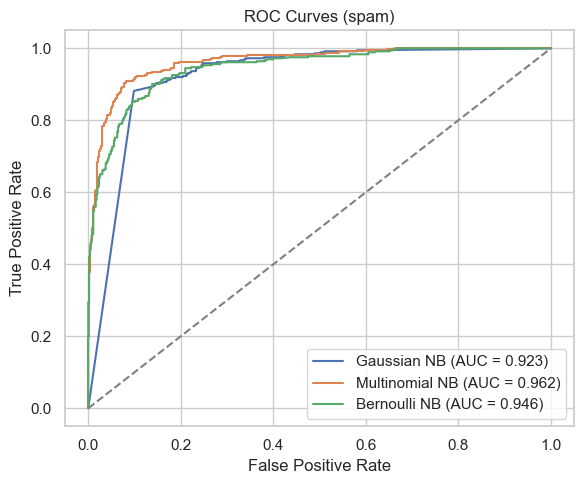

In [131]:
plot_roc_curves(nb_proba_for_curves, 'spam')

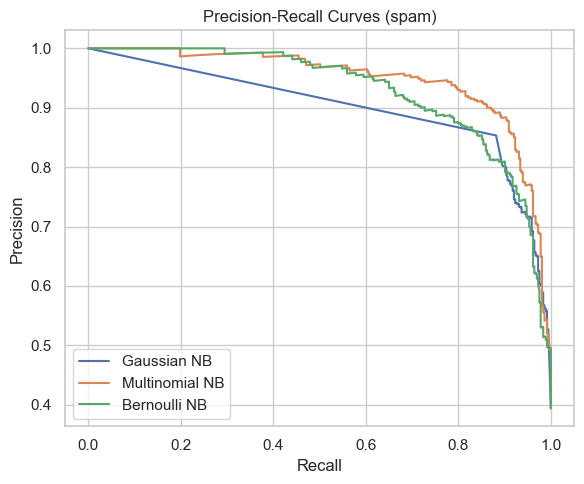

In [132]:
plot_precision_recall_curves(nb_proba_for_curves, 'spam')

##### KNN with k varied across the values [1, 3, 5, 7, 9, 11]

In [133]:
def evaluate_knn_over_k(X_train, y_train, X_test, y_test, k_values):
    rows = []
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        _, y_pred, y_proba = train_model(model, X_train, y_train, X_test)
        row = {'k': k}
        row.update(get_classification_metrics(y_test, y_pred, y_proba))
        rows.append(row)
    return pd.DataFrame(rows).set_index('k')

In [134]:
def plot_accuracy_vs_k(knn_k_results, dataset):
    plt.figure(figsize=(6, 4))
    plt.plot(knn_k_results.index, knn_k_results['Accuracy'], marker='o')
    plt.xlabel('k')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy vs k ({dataset})')
    pp.save_plot(dataset, 'accuracy-vs-k')

In [135]:
knn_k_results = evaluate_knn_over_k(X_train, y_train, X_test, y_test, [1, 3, 5, 7, 9, 11])
knn_k_results

,Accuracy,Precision,Recall,F1,ROC-AUC
k,,,,,
1,0.895765,0.867769,0.867769,0.867769,0.890874
3,0.895765,0.882521,0.848485,0.865169,0.931357
5,0.902280,0.876033,0.876033,0.876033,0.941944
7,0.895765,0.876056,0.856749,0.866295,0.946439
9,0.894680,0.886628,0.840220,0.862801,0.950087
11,0.889251,0.882698,0.829201,0.855114,0.952914


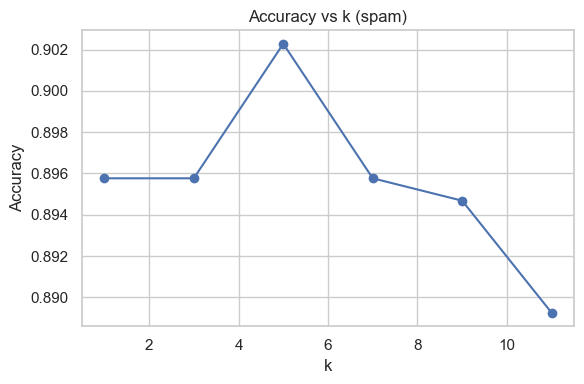

In [136]:
plot_accuracy_vs_k(knn_k_results, 'spam')

##### KNN tuned in two ways: an exhaustive GridSearchCV over a small grid and a RandomizedSearchCV that samples from the same space

In [137]:
def tune_knn_gridsearch(X_train, y_train, param_grid=None, cv=5):
    if param_grid is None:
        param_grid = {
            'n_neighbors': [1, 3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'algorithm': ['auto', 'kd_tree', 'ball_tree'],
        }
    start = time.time()
    search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    search.fit(X_train, y_train)
    elapsed = time.time() - start
    return search, elapsed

In [138]:
def tune_knn_randomizedsearch(X_train, y_train, param_distributions=None, n_iter=15, cv=5):
    if param_distributions is None:
        param_distributions = {
            'n_neighbors': list(range(1, 22, 2)),
            'weights': ['uniform', 'distance'],
            'algorithm': ['auto', 'kd_tree', 'ball_tree'],
        }
    start = time.time()
    search = RandomizedSearchCV(KNeighborsClassifier(), param_distributions, n_iter=n_iter, cv=cv,
                                 scoring='accuracy', n_jobs=-1, random_state=RANDOM_STATE)
    search.fit(X_train, y_train)
    elapsed = time.time() - start
    return search, elapsed

In [139]:
def plot_gridsearch_heatmap(search, dataset, row_param='n_neighbors', col_param='weights'):
    results = pd.DataFrame(search.cv_results_)
    pivot = results.pivot_table(values='mean_test_score', index=f'param_{row_param}', columns=f'param_{col_param}')
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu')
    plt.title(f'GridSearchCV Accuracy Heatmap ({dataset})')
    pp.save_plot(dataset, 'gridsearch-heatmap')

In [140]:
def plot_randomizedsearch_distribution(search, dataset):
    scores = search.cv_results_['mean_test_score']
    plt.figure(figsize=(6, 4))
    sns.histplot(scores, kde=True, color='mediumpurple')
    plt.xlabel('Mean CV Accuracy')
    plt.title(f'RandomizedSearchCV Score Distribution ({dataset})')
    pp.save_plot(dataset, 'randomsearch-distribution')

In [141]:
grid_search, grid_time = tune_knn_gridsearch(X_train, y_train)
random_search, random_time = tune_knn_randomizedsearch(X_train, y_train)

grid_search.best_params_, random_search.best_params_

({'algorithm': 'auto', 'n_neighbors': 11, 'weights': 'distance'},
 {'weights': 'distance', 'n_neighbors': 11, 'algorithm': 'kd_tree'})

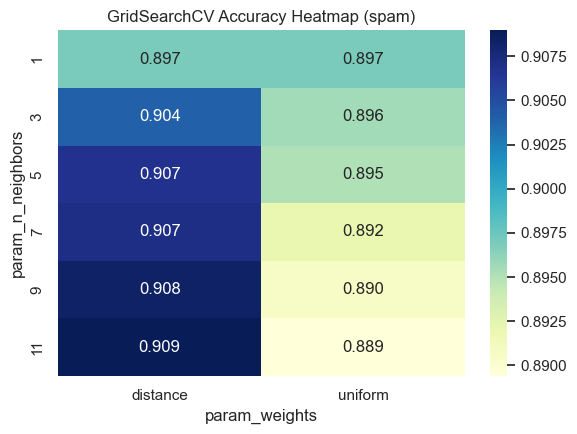

In [142]:
plot_gridsearch_heatmap(grid_search, 'spam')

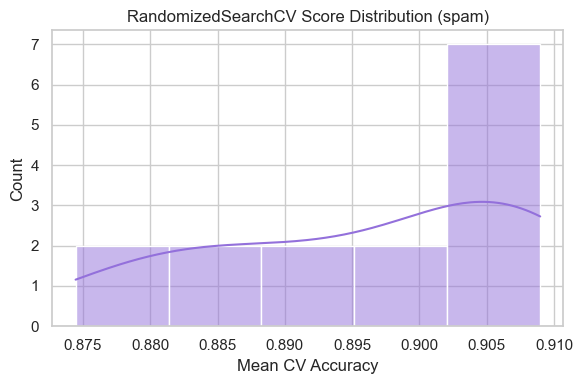

In [143]:
plot_randomizedsearch_distribution(random_search, 'spam')

In [144]:
search_comparison = pd.DataFrame({
    'GridSearchCV': {
        'Best k': grid_search.best_params_['n_neighbors'],
        'Weights': grid_search.best_params_['weights'],
        'Algorithm': grid_search.best_params_['algorithm'],
        'CV Accuracy': grid_search.best_score_,
        'Execution Time (s)': grid_time,
    },
    'RandomizedSearchCV': {
        'Best k': random_search.best_params_['n_neighbors'],
        'Weights': random_search.best_params_['weights'],
        'Algorithm': random_search.best_params_['algorithm'],
        'CV Accuracy': random_search.best_score_,
        'Execution Time (s)': random_time,
    },
})
search_comparison

,GridSearchCV,RandomizedSearchCV
Best k,11,11
Weights,distance,distance
Algorithm,auto,kd_tree
CV Accuracy,0.908967,0.908967
Execution Time (s),3.757386,0.617626


In [145]:
def compare_tree_algorithms(X_train, y_train, X_test, y_test, k, weights='uniform'):
    rows = {}
    for algorithm in ['kd_tree', 'ball_tree']:
        model = KNeighborsClassifier(n_neighbors=k, weights=weights, algorithm=algorithm)

        start = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start

        start = time.time()
        y_pred = model.predict(X_test)
        predict_time = time.time() - start

        rows[algorithm] = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Training Time (s)': train_time,
            'Prediction Time (s)': predict_time,
        }
    return pd.DataFrame(rows)

In [146]:
best_k = grid_search.best_params_['n_neighbors']
best_weights = grid_search.best_params_['weights']

tree_comparison = compare_tree_algorithms(X_train, y_train, X_test, y_test, best_k, best_weights)
tree_comparison

,kd_tree,ball_tree
Accuracy,0.903366,0.903366
Training Time (s),0.004614,0.002859
Prediction Time (s),0.093432,0.082386


##### Cross validation

In [147]:
def cross_validate_models(models, X, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = {}
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
        fold_scores[name] = scores
    fold_df = pd.DataFrame(fold_scores, index=[f'Fold {i+1}' for i in range(cv)])
    fold_df.loc['Average'] = fold_df.mean()
    return fold_df

In [148]:
def plot_cv_accuracy(fold_df, dataset):
    plot_df = fold_df.drop(index='Average')
    plt.figure(figsize=(6, 4))
    for col in plot_df.columns:
        plt.plot(plot_df.index, plot_df[col], marker='o', label=col)
    plt.ylabel('Accuracy')
    plt.title(f'Cross-Validation Accuracy ({dataset})')
    plt.xticks(rotation=20)
    plt.legend()
    pp.save_plot(dataset, 'cv-accuracy')

In [149]:
best_nb_name = nb_comparison['Accuracy'].idxmax()

cv_models = {
    'Naive Bayes': nb_models[best_nb_name],
    'Best KNN': KNeighborsClassifier(n_neighbors=best_k, weights=best_weights, algorithm=grid_search.best_params_['algorithm']),
}

cv_results = cross_validate_models(cv_models, X_norm, y, cv=5)
cv_results

,Naive Bayes,Best KNN
Fold 1,0.887079,0.914224
Fold 2,0.885870,0.917391
Fold 3,0.894565,0.918478
Fold 4,0.890217,0.915217
Fold 5,0.880435,0.901087
Average,0.887633,0.913280


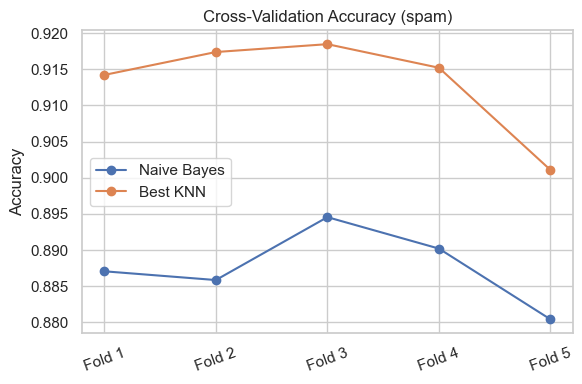

In [150]:
plot_cv_accuracy(cv_results, 'spam')

##### Theoretical time complexity for each algorithm

In [151]:
pd.DataFrame({
        'Training': ['O(nd)', 'O(1)', 'O(n log n)', 'O(n log n)'],
        'Prediction': ['O(d)', 'O(nd)', 'O(log n) avg', 'O(log n) avg'],
    }, index=['Naive Bayes', 'KNN (Brute)', 'KDTree', 'BallTree'])

,Training,Prediction
Naive Bayes,O(nd),O(d)
KNN (Brute),O(1),O(nd)
KDTree,O(n log n),O(log n) avg
BallTree,O(n log n),O(log n) avg


##### Measured training and prediction time

In [152]:
def measure_execution_time(model, X_train, y_train, X_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    model.predict(X_test)
    predict_time = time.time() - start

    return train_time, predict_time

In [153]:
def plot_time_comparison(time_df, column, dataset, plot_name):
    plt.figure(figsize=(6, 4))
    sns.barplot(x=time_df.index, y=time_df[column], hue=time_df.index, palette='crest', legend=False)
    plt.ylabel(column)
    plt.title(f'{column} Comparison ({dataset})')
    plt.xticks(rotation=15)
    pp.save_plot(dataset, plot_name)

In [154]:
timing_models = {
    'Gaussian NB': GaussianNB(),
    'Multinomial NB': MultinomialNB(),
    'Bernoulli NB': BernoulliNB(),
    'Best KNN': KNeighborsClassifier(n_neighbors=best_k, weights=best_weights, algorithm=grid_search.best_params_['algorithm']),
}

timing_rows = {}
for name, model in timing_models.items():
    train_t, predict_t = measure_execution_time(model, X_train, y_train, X_test)
    timing_rows[name] = {'Training (s)': train_t, 'Prediction (s)': predict_t}

experimental_time = pd.DataFrame(timing_rows).T
experimental_time

,Training (s),Prediction (s)
Gaussian NB,0.003476,0.001292
Multinomial NB,0.002135,0.001169
Bernoulli NB,0.003233,0.001346
Best KNN,0.001610,0.007966


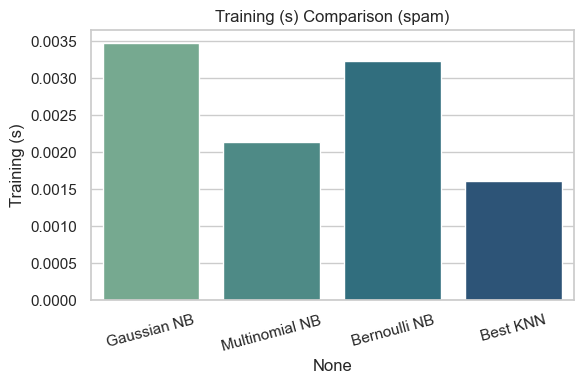

In [155]:
plot_time_comparison(experimental_time, 'Training (s)', 'spam', 'training-time-comparison')

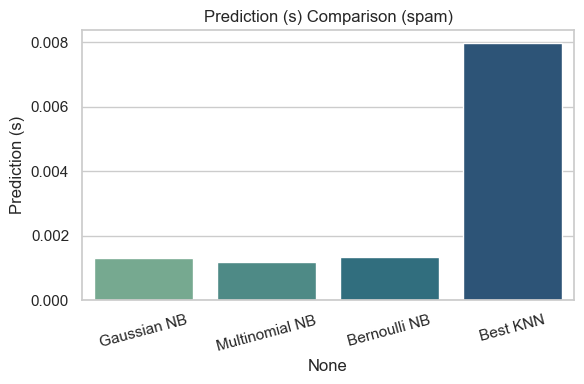

In [156]:
plot_time_comparison(experimental_time, 'Prediction (s)', 'spam', 'prediction-time-comparison')

In [157]:
def plot_classifier_comparison(all_results, dataset):
    comp_df = pd.DataFrame(all_results).T
    comp_df[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar', figsize=(8, 4.5))
    plt.ylabel('Score')
    plt.title(f'Classifier Comparison ({dataset})')
    plt.xticks(rotation=15)
    plt.legend(loc='lower right')
    pp.save_plot(dataset, 'classifier-comparison')

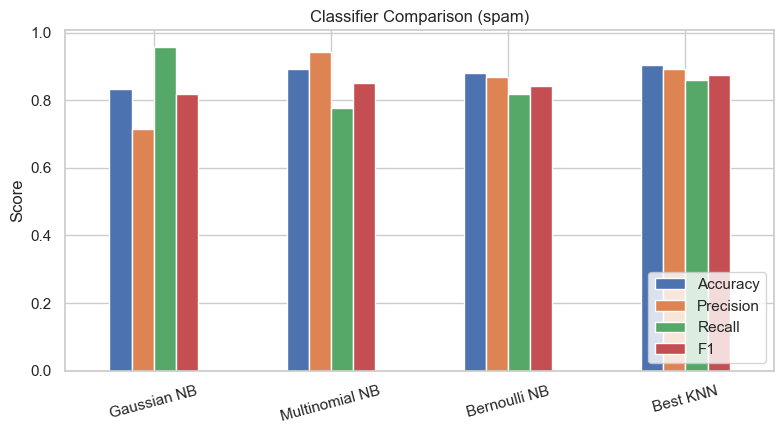

,Accuracy,Precision,Recall,F1,ROC-AUC
Gaussian NB,0.832790,0.714579,0.958678,0.818824,0.922917
Multinomial NB,0.893594,0.943144,0.776860,0.851964,0.962454
Bernoulli NB,0.879479,0.868421,0.818182,0.842553,0.945674
Best KNN,0.903366,0.891429,0.859504,0.875175,0.962677


In [158]:
_, best_knn_pred, best_knn_proba = train_model(
    KNeighborsClassifier(n_neighbors=best_k, weights=best_weights, algorithm=grid_search.best_params_['algorithm']),
    X_train, y_train, X_test
)

all_results = dict(nb_results)
all_results['Best KNN'] = get_classification_metrics(y_test, best_knn_pred, best_knn_proba)

plot_classifier_comparison(all_results, 'spam')
pd.DataFrame(all_results).T

##### Checking how sensitive results are to the train-test split ratio, comparing Euclidean and Manhattan distance for KNN, and comparing uniform weighting against distance weighting

In [159]:
def evaluate_train_test_splits(X, y, model, test_sizes=(0.1, 0.2, 0.3, 0.4)):
    rows = {}
    for size in test_sizes:
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=size, stratify=y, random_state=RANDOM_STATE)
        _, y_pred, y_proba = train_model(model, X_tr, y_tr, X_te)
        rows[f'{int((1-size)*100)}/{int(size*100)}'] = get_classification_metrics(y_te, y_pred, y_proba)
    return pd.DataFrame(rows).T

In [160]:
split_results = evaluate_train_test_splits(
    X_norm, y,
    KNeighborsClassifier(n_neighbors=best_k, weights=best_weights, algorithm=grid_search.best_params_['algorithm'])
)
split_results

,Accuracy,Precision,Recall,F1,ROC-AUC
90/10,0.898048,0.877095,0.862637,0.869806,0.963656
80/20,0.903366,0.891429,0.859504,0.875175,0.962677
70/30,0.913106,0.898496,0.878676,0.888476,0.964345
60/40,0.906573,0.898990,0.859310,0.878702,0.959398


In [161]:
def compare_distance_metrics(X_train, y_train, X_test, y_test, k):
    rows = {}
    for metric in ['euclidean', 'manhattan']:
        model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        _, y_pred, y_proba = train_model(model, X_train, y_train, X_test)
        rows[metric] = get_classification_metrics(y_test, y_pred, y_proba)
    return pd.DataFrame(rows).T

In [162]:
distance_comparison = compare_distance_metrics(X_train, y_train, X_test, y_test, best_k)
distance_comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
euclidean,0.889251,0.882698,0.829201,0.855114,0.952914
manhattan,0.900109,0.930159,0.807163,0.864307,0.958966


In [163]:
def evaluate_weighted_knn(X_train, y_train, X_test, y_test, k):
    rows = {}
    for weights in ['uniform', 'distance']:
        model = KNeighborsClassifier(n_neighbors=k, weights=weights)
        _, y_pred, y_proba = train_model(model, X_train, y_train, X_test)
        rows[weights] = get_classification_metrics(y_test, y_pred, y_proba)
    return pd.DataFrame(rows).T

In [164]:
weighted_knn_results = evaluate_weighted_knn(X_train, y_train, X_test, y_test, best_k)
weighted_knn_results

,Accuracy,Precision,Recall,F1,ROC-AUC
uniform,0.889251,0.882698,0.829201,0.855114,0.952914
distance,0.903366,0.891429,0.859504,0.875175,0.962677


#### Naive Bayes
- Multinomial NB has the highest accuracy and ROC-AUC
- Gaussian NB has the best recall (0.96) so it catches almost all spam at the cost of precision (0.71, so it also misclassifies a lot of real mail as spam)
- Multinomial NB is the opposite: high precision, weaker recall
- So Multinomial NB is best overall, but if the priority is oto never let spam through, Gaussian NB is  more useful despite its lower accuracy. 

#### K Nearest Neighbours
- The k value(uniform weights, k = 1,3,5,7,9,11) peaks at k=5 (0.9023) dips slightly at k=1 (0.8958) and drifts down again by k=11 (0.8893)
- GridSearchCV and RandomizedSearchCV both converged on k=11, weights='distance', with identical CV accuracy of 0.908967
- It is because the sweep only tested weights='uniform', while the tuned search also did weights='distance' and found it better at higher k